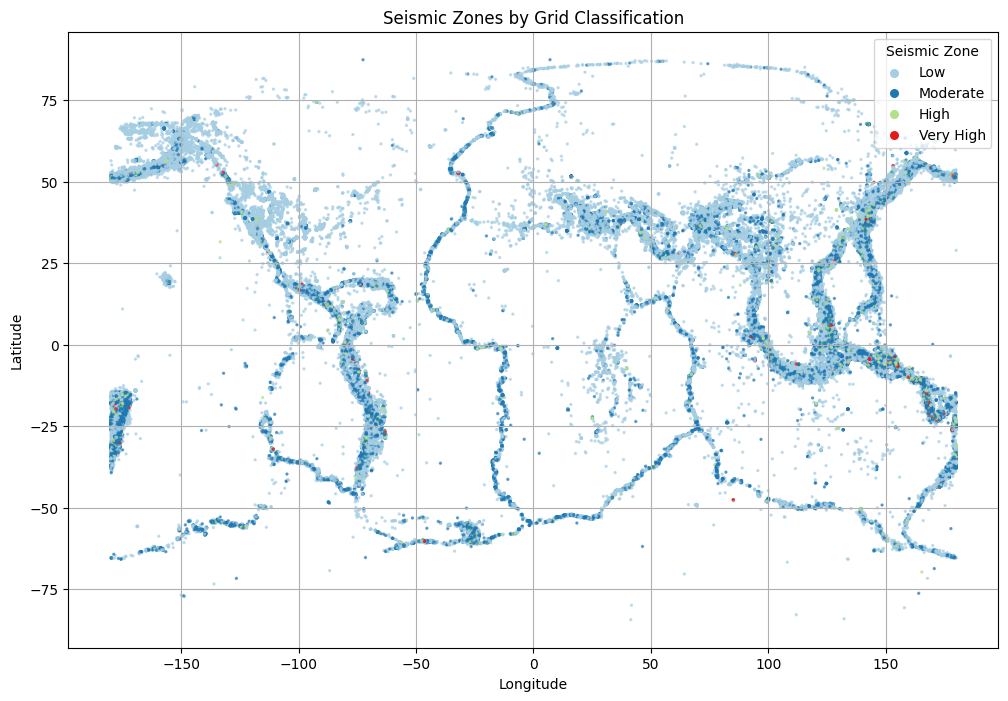

In [2]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv("C:/Users/theta/Downloads/cleaned_earthquakes.csv")  
df = df.drop('seismic_zone', axis=1) # axis=1 indicates dropping a column

# Define grid resolution (in degrees)
grid_size = 0.25  

# Create grid bins
df['lat_bin'] = np.floor(df['latitude'] / grid_size).astype(int)
df['lon_bin'] = np.floor(df['longitude'] / grid_size).astype(int)

# Create a unique grid ID
df['grid_id'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

# Group by grid_id and compute both metrics
grid_stats = df.groupby('grid_id').agg({
    'mag': ['max', 'mean', 'count']
}).reset_index()

# Rename columns for clarity
grid_stats.columns = ['grid_id', 'max_mag', 'mean_mag', 'event_count']

def assign_seismic_zone(mag):
    if mag < 5.0:
        return 'Low'
    elif 5.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'High'
    else:
        return 'Very High'

grid_stats['seismic_zone'] = grid_stats['max_mag'].apply(assign_seismic_zone)
df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')

import matplotlib.pyplot as plt

# Define a color map for seismic zones
zone_colors = {
    'Low': '#a6cee3',
    'Moderate': '#1f78b4',
    'High': '#b2df8a',
    'Very High': '#e31a1c'
}

# Map colors to each row
df['zone_color'] = df['seismic_zone'].map(zone_colors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['zone_color'], s=2, alpha=0.6)
plt.title('Seismic Zones by Grid Classification')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)

# Create legend
for zone, color in zone_colors.items():
    plt.scatter([], [], c=color, label=zone, s=30)
plt.legend(title='Seismic Zone', loc='upper right')

plt.show()

seismic_zone
Low          29881
Moderate      9523
High          1401
Very High      194
Name: count, dtype: int64


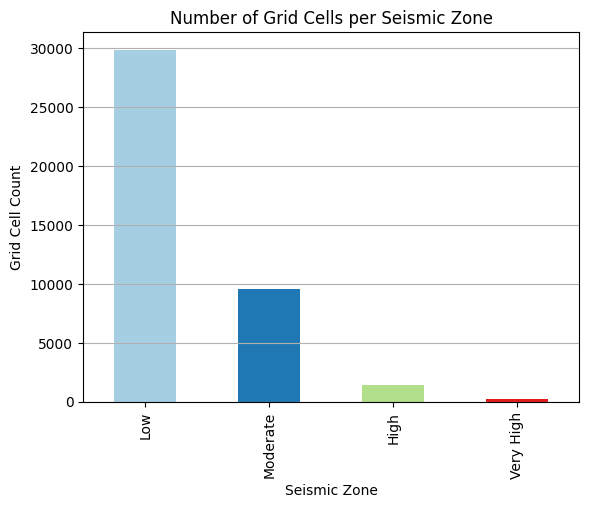

In [3]:
grid_counts = grid_stats['seismic_zone'].value_counts()

zone_order = ['Low', 'Moderate', 'High', 'Very High']
grid_counts = grid_counts.reindex(zone_order)

print(grid_counts)

import matplotlib.pyplot as plt

grid_counts.plot(kind='bar', color=['#a6cee3', '#1f78b4', '#b2df8a', '#e31a1c'])
plt.title('Number of Grid Cells per Seismic Zone')
plt.xlabel('Seismic Zone')
plt.ylabel('Grid Cell Count')
plt.grid(axis='y')
plt.show()

TRAINING MODELS ON GRID CLASSIFY

C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:183: UserWarning: [15:58:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KNN:               precision    recall  f1-score   support

        High       0.89      0.92      0.90      6401
         Low       0.92      0.88      0.90     19490
    Moderate       0.89      0.92      0.90     21510
   Very High       0.88      0.90      0.89      1222

    accuracy                           0.90     48623
   macro avg       0.89      0.90      0.90     48623
weighted avg       0.90      0.90      0.90     48623

Random Forest:               precision    recall  f1-score   support

        High       0.96      0.94      0.95      6401
         Low       0.92      0.93      0.92     19490
    Moderate       0.93      0.93      0.93     21510
   Very High       0.97      0.94      0.96      1222

    accuracy                           0.93     48623
   macro avg       0.95      0.94      0.94     48623
weighted avg       0.93      0.93      0.93     48623

Logistic Regression:               precision    recall  f1-score   support

        High       0.00      0.00 

C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

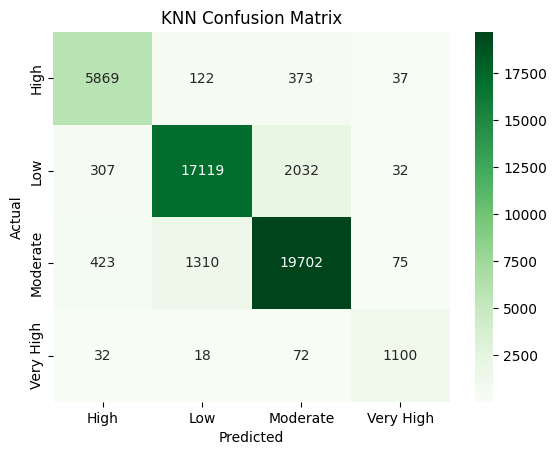

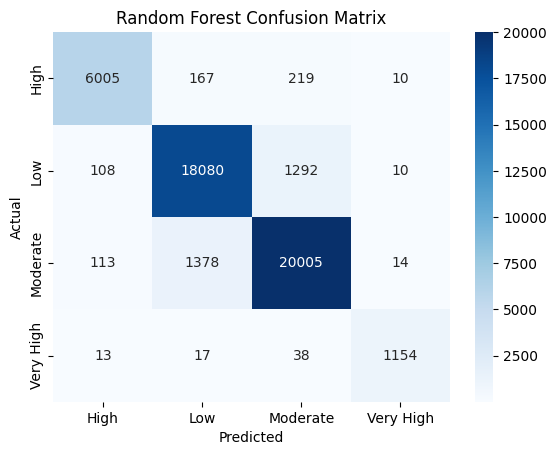

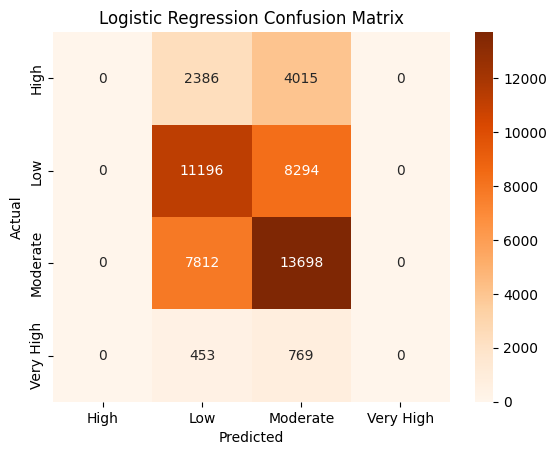

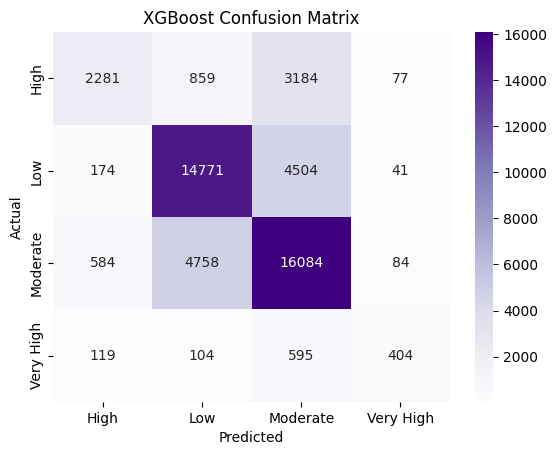

In [4]:
from sklearn.preprocessing import LabelEncoder

# Encode seismic zones as numeric labels
le = LabelEncoder()
df['zone_label'] = le.fit_transform(df['seismic_zone'])

# Features and labels
X = df[['latitude', 'longitude']]
y = df['zone_label']

from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose model
modelK = KNeighborsClassifier(n_neighbors=3)
modelR = RandomForestClassifier(n_estimators=100, random_state=42)
modelL = LogisticRegression(max_iter=1000, random_state=42)
modelX = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train
modelK.fit(X_train, y_train)
modelR.fit(X_train, y_train)
modelL.fit(X_train, y_train)
modelX.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_predK = modelK.predict(X_test)
report = classification_report(y_test, y_predK, target_names=le.classes_)
print("KNN:", report)

y_predR = modelR.predict(X_test)
report2 = classification_report(y_test, y_predR, target_names=le.classes_)
print("Random Forest:", report2)

y_predL = modelL.predict(X_test)
reportL = classification_report(y_test, y_predL, target_names=le.classes_)
print("Logistic Regression:", reportL)

y_predX = modelX.predict(X_test)
reportX = classification_report(y_test, y_predX, target_names=le.classes_)
print("XGBoost:", reportX)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KNN
cm_knn = confusion_matrix(y_test, y_predK)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_predR)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_predL)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XGBoost
cm_xgb = confusion_matrix(y_test, y_predX)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Not going to use XGBoost or Regression, KNN or Random Classifer work best

TRAINING KNN ON INDIVIDUAL CLASSIFY

Confusion Matrix:
[[   31    29   883     0]
 [    4  6967  1019     0]
 [  219  3022 35984     0]
 [    1     3    48     0]]

Classification Report:


C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

              precision    recall  f1-score   support

        high       0.12      0.03      0.05       943
         low       0.70      0.87      0.77      7990
    moderate       0.95      0.92      0.93     39225
   very high       0.00      0.00      0.00        52

    accuracy                           0.89     48210
   macro avg       0.44      0.46      0.44     48210
weighted avg       0.89      0.89      0.89     48210



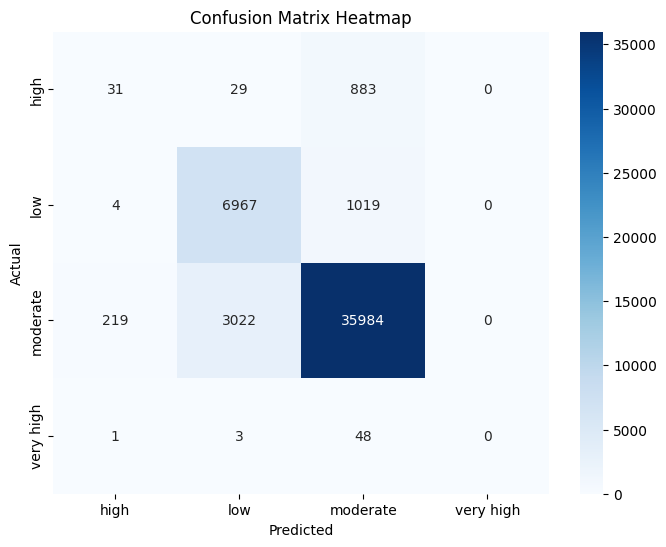

In [5]:
#first trial

data = pd.read_csv("C:/Users/theta/Downloads/cleaned_earthquakes.csv")  
data = data.drop('seismic_zone', axis=1)

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

earthquake_data = data[data['type'] == 'earthquake']

conditions = [
    earthquake_data['mag'] < 3.5,
    (earthquake_data['mag'] >= 3.5) & (earthquake_data['mag'] <= 5.5),
    (earthquake_data['mag'] > 5.5) & (earthquake_data['mag'] <= 6.9),
    earthquake_data['mag'] >= 7.0
]
choices = ['low', 'moderate', 'high', 'very high']

seismic_zone_class= np.select(conditions, choices, default='unknown')
x = earthquake_data[['longitude', 'latitude']]
y = seismic_zone_class

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2)

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

Confusion Matrix:
[[ 4780    45   864    10]
 [  193 11195   561     3]
 [ 4263  2610 22381   117]
 [    8     0    66   288]]

Classification Report:
              precision    recall  f1-score   support

        high       0.52      0.84      0.64      5699
         low       0.81      0.94      0.87     11952
    moderate       0.94      0.76      0.84     29371
   very high       0.69      0.80      0.74       362

    accuracy                           0.82     47384
   macro avg       0.74      0.83      0.77     47384
weighted avg       0.85      0.82      0.82     47384



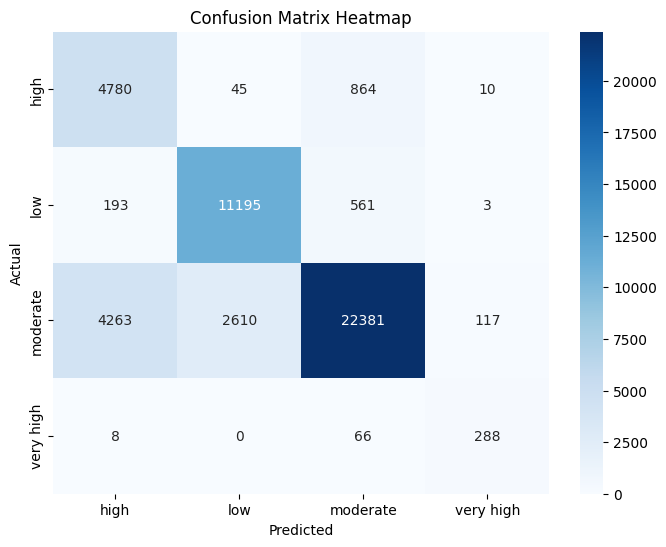

In [6]:
#augmented

earthquake_data = data[data['type'] == 'earthquake'].copy()

earthquake_data['seismic_zone_class'] = np.select(conditions, choices, default='unknown')


low_data = earthquake_data[earthquake_data['seismic_zone_class'] == 'low']
moderate_data = earthquake_data[earthquake_data['seismic_zone_class'] == 'moderate']
high_data = earthquake_data[earthquake_data['seismic_zone_class'] == 'high']
very_high_data = earthquake_data[earthquake_data['seismic_zone_class'] == 'very high']

low_increase= pd.concat([low_data] *3, ignore_index=True)
moderate_reduced = moderate_data.sample(frac=0.5, random_state=42)
high_increase= pd.concat([high_data] *4, ignore_index=True)
very_high_increase = pd.concat([very_high_data] *6, ignore_index=True)

balanced_data = pd.concat([low_data, moderate_reduced, high_increase, very_high_increase], ignore_index=True)


x = balanced_data[['longitude', 'latitude']]
y = balanced_data['seismic_zone_class']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)


knn_better_model = KNeighborsClassifier(n_neighbors=4)
knn_better_model.fit(x_train, y_train)
y_pred = knn_better_model.predict(x_test)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

APPLYING TO NEW DATA

seismic_zone
Low          7473
Moderate      912
High           67
Very High       7
Name: count, dtype: int64
KNN on New Data:
              precision    recall  f1-score   support

        High       0.01      0.03      0.01       567
         Low       0.81      0.56      0.66     14977
    Moderate       0.19      0.38      0.26      3600
   Very High       0.13      0.14      0.14       183

    accuracy                           0.50     19327
   macro avg       0.29      0.28      0.27     19327
weighted avg       0.66      0.50      0.56     19327

Random Forest on New Data:
              precision    recall  f1-score   support

        High       0.01      0.03      0.01       567
         Low       0.82      0.59      0.68     14977
    Moderate       0.21      0.39      0.27      3600
   Very High       0.16      0.16      0.16       183

    accuracy                           0.53     19327
   macro avg       0.30      0.29      0.28     19327
weighted avg       0.67      0

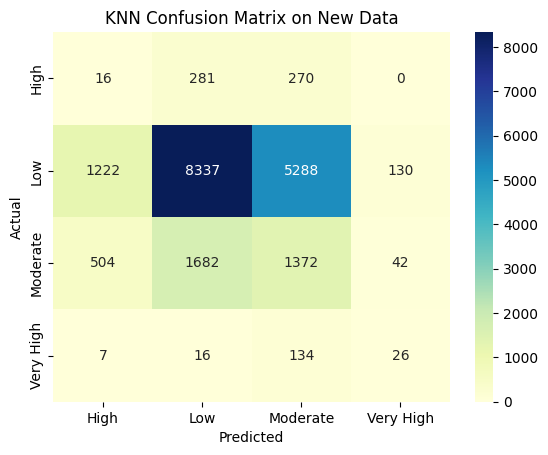

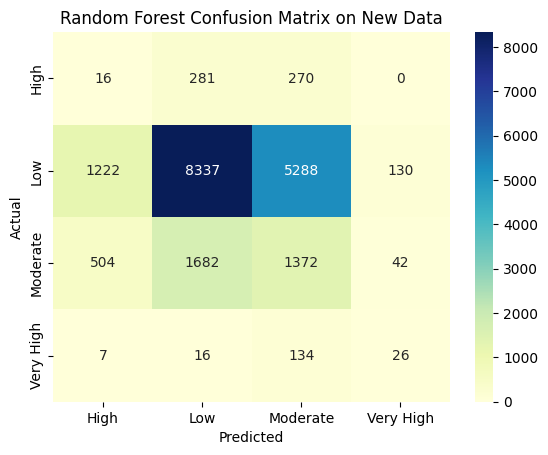

In [8]:
#GRID CLASSIFY

import pandas as pd
import numpy as np

# Load your dataset
df2 = pd.read_csv("C:/Users/theta/Downloads/query (1).csv")  # Replace with your actual file path

# Define grid resolution (in degrees)
grid_size = 0.25 # You can tune this later

# Create grid bins
df2['lat_bin'] = np.floor(df2['latitude'] / grid_size).astype(int)
df2['lon_bin'] = np.floor(df2['longitude'] / grid_size).astype(int)

# Create a unique grid ID
df2['grid_id'] = df2['lat_bin'].astype(str) + '_' + df2['lon_bin'].astype(str)

# Group by grid_id and compute both metrics
grid_stats = df2.groupby('grid_id').agg({
    'mag': ['max', 'mean', 'count']
}).reset_index()

# Rename columns for clarity
grid_stats.columns = ['grid_id', 'max_mag', 'mean_mag', 'event_count']

# Define weights (you can tune these later)
# w_max = 0.7
# w_mean = 0.3

# # Compute hybrid score
# grid_stats['zone_score'] = w_max * grid_stats['max_mag'] + w_mean * grid_stats['mean_mag'] #for this, the function should have score instead of mag

def assign_seismic_zone(mag):
    if mag < 5.0:
        return 'Low'
    elif 5.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'High'
    else:
        return 'Very High'

grid_stats['seismic_zone'] = grid_stats['max_mag'].apply(assign_seismic_zone)
df2 = df2.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')
# grid_stats['seismic_zone'] = grid_stats['zone_score'].apply(assign_seismic_zone)
# df = df.merge(grid_stats[['grid_id', 'seismic_zone']], on='grid_id', how='left')

grid_counts = grid_stats['seismic_zone'].value_counts()

zone_order = ['Low', 'Moderate', 'High', 'Very High']
grid_counts = grid_counts.reindex(zone_order)

print(grid_counts)

# Encode seismic_zone in df2 using the same label encoder
df2['zone_label'] = le.transform(df2['seismic_zone'])  # use the same 'le' from training

# Extract features and labels
X_new = df2[['latitude', 'longitude']]
y_new = df2['zone_label']

y_pred_new = modelK.predict(X_new)
y_pred_newR = modelR.predict(X_new)

from sklearn.metrics import classification_report, confusion_matrix

print("KNN on New Data:")
print(classification_report(y_new, y_pred_new, target_names=le.classes_))

print("Random Forest on New Data:")
print(classification_report(y_new, y_pred_newR, target_names=le.classes_))

cm_new = confusion_matrix(y_new, y_pred_new)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix on New Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm_newR = confusion_matrix(y_new, y_pred_new)
sns.heatmap(cm_newR, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix on New Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Confusion Matrix:
[[  49   47  123    0]
 [   4 6605  292    0]
 [2270 1987 7774    0]
 [   2    2    3    0]]

Classification Report:
              precision    recall  f1-score   support

        high       0.02      0.22      0.04       219
         low       0.76      0.96      0.85      6901
    moderate       0.95      0.65      0.77     12031
   very high       0.00      0.00      0.00         7

    accuracy                           0.75     19158
   macro avg       0.43      0.46      0.41     19158
weighted avg       0.87      0.75      0.79     19158



C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\theta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

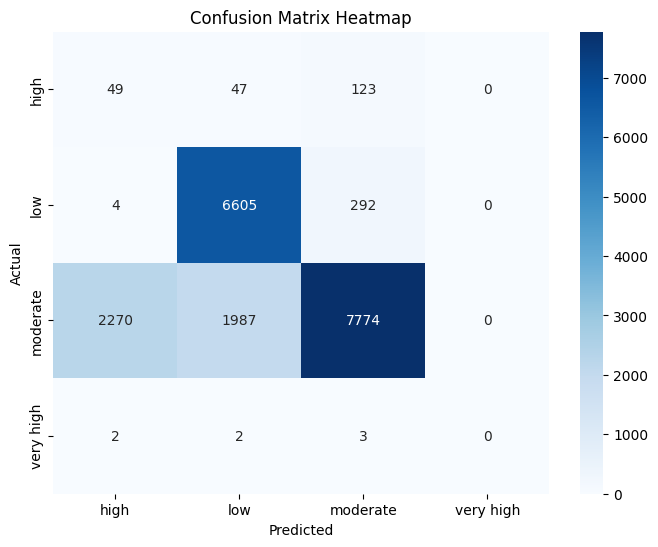

In [9]:
#INDIVIDUAL CLASSIFY

data2 = pd.read_csv("C:/Users/theta/Downloads/query (1).csv")  # Replace with your actual file path

earthquake_data2 = data2[data2['type'] == 'earthquake']

conditions2 = [
    earthquake_data2['mag'] < 3.5,
    (earthquake_data2['mag'] >= 3.5) & (earthquake_data2['mag'] <= 5.5),
    (earthquake_data2['mag'] > 5.5) & (earthquake_data2['mag'] <= 6.9),
    earthquake_data2['mag'] >= 7.0
]
choices2 = ['low', 'moderate', 'high', 'very high']

seismic_zone_class2 = np.select(conditions2, choices2, default='unknown')
x2 = earthquake_data2[['longitude', 'latitude']]
y2 = seismic_zone_class2

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x2)

y_pred_new = knn.predict(x2)

print("Confusion Matrix:")
print(confusion_matrix(y2, y_pred_new))

print("\nClassification Report:")
print(classification_report(y2, y_pred_new))

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y2, y_pred_new), annot=True, fmt='d',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()